In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ---------------------------------------------------------
# 1. PARÂMETROS E PROPRIEDADES (Unidades: kN, mm)
# ---------------------------------------------------------
E = 200.0  # Módulo de Elasticidade em kN/mm² (200000 MPa)
nu = 0.3   # Coeficiente de Poisson (ex: 0.3 para aço)
G = E / (2.0 * (1.0 + nu)) # Módulo de Cisalhamento Transversal

# Momentos de Inércia (mm^4) calculados previamente
I_A = 1653007211.6245 
I_B = 334482563.4911  

# --- PARÂMETROS PARA TIMOSHENKO (PERFIL I) ---
# A área efetiva de cisalhamento (As) para perfis I é a área bruta da alma (h * tw)
As_A = 800.0 * 12.7  # = 10160.0 mm²
As_B = 400.0 * 12.7  # = 5080.0 mm²

# Coordenadas dos nós ao longo do eixo X (mm)
nos = np.array([0, 400, 800, 1200, 1600, 2600, 3000, 3400, 3800, 4200], dtype=float)
n_nos = len(nos)
n_gl = n_nos * 2  

# Definição dos elementos: [no_i, no_j, Inercia_do_elemento, Area_Cisalhamento]
elementos = [
    [0, 1, I_A, As_A],
    [1, 2, I_A, As_A],
    [2, 3, I_A, As_A],
    [3, 4, I_A, As_A],
    [4, 5, I_B, As_B], # Tramo Central
    [5, 6, I_A, As_A],
    [6, 7, I_A, As_A],
    [7, 8, I_A, As_A],
    [8, 9, I_A, As_A]
]

# ---------------------------------------------------------
# 2. MONTAGEM DA MATRIZ DE RIGIDEZ GLOBAL E VETOR DE FORÇAS
# ---------------------------------------------------------
K_global = np.zeros((n_gl, n_gl))
F_global = np.zeros(n_gl)

# Matriz de rigidez do elemento de viga de Timoshenko
def matriz_rigidez_viga_timoshenko(E, G, I, As, L):
    Phi = (12.0 * E * I) / (G * As * L**2)
    c = (E * I) / (L**3 * (1.0 + Phi))
    return c * np.array([
        [12,           6*L,             -12,           6*L],
        [6*L,          (4+Phi)*L**2,    -6*L,          (2-Phi)*L**2],
        [-12,          -6*L,             12,           -6*L],
        [6*L,          (2-Phi)*L**2,    -6*L,          (4+Phi)*L**2]
    ])

for el in elementos:
    no_i, no_j, I_el, As_el = el
    L = nos[no_j] - nos[no_i]
    
    K_el = matriz_rigidez_viga_timoshenko(E, G, I_el, As_el, L)
    gls = [2*no_i, 2*no_i+1, 2*no_j, 2*no_j+1]
    
    for i in range(4):
        for j in range(4):
            K_global[gls[i], gls[j]] += K_el[i, j]

# Aplicação das cargas pontuais de 30 kN
nos_com_carga = [1, 2, 3, 6, 7, 8]
for no in nos_com_carga:
    F_global[2 * no] = -30.0

# ---------------------------------------------------------
# 3. CONDIÇÕES DE CONTORNO E SOLUÇÃO
# ---------------------------------------------------------
gls_restritos = [0, 18] # Nós 0 e 9 restritos na vertical
gls_livres = [i for i in range(n_gl) if i not in gls_restritos]

K_red = K_global[np.ix_(gls_livres, gls_livres)]
F_red = F_global[gls_livres]

D_red = np.linalg.solve(K_red, F_red)

D_global = np.zeros(n_gl)
D_global[gls_livres] = D_red

# ---------------------------------------------------------
# 4. CÁLCULO DE REAÇÕES E ESFORÇOS INTERNOS
# ---------------------------------------------------------
F_reacoes = K_global.dot(D_global)
R_esq = F_reacoes[0]
R_dir = F_reacoes[18]

V_elems = []
X_m = []
M_z = []

for el in elementos:
    no_i, no_j, I_el, As_el = el
    L = nos[no_j] - nos[no_i]
    
    K_el = matriz_rigidez_viga_timoshenko(E, G, I_el, As_el, L)
    gls = [2*no_i, 2*no_i+1, 2*no_j, 2*no_j+1]
    d_el = D_global[gls]
    f_el = K_el.dot(d_el)
    
    V_elems.append(f_el[0])
    X_m.extend([nos[no_i], nos[no_j]])
    M_z.extend([-f_el[1], f_el[3]])

V_elems.append(V_elems[-1])

# ---------------------------------------------------------
# 5. FUNÇÕES DE DESENHO DE APOIOS E FORMATAÇÃO 
# ---------------------------------------------------------
def desenhar_apoio_2_ordem(ax, x, y_base, dy, dx):
    h = dy * 0.15
    w = dx * 0.015

    ax.plot([x, x-w, x+w, x],
            [y_base, y_base-h, y_base-h, y_base],
            'b-', lw=1.5, zorder=5, clip_on=False)

    ax.plot([x-w*1.5, x+w*1.5],
            [y_base-h, y_base-h],
            'k-', lw=2, zorder=5, clip_on=False)

    for i in np.linspace(-w*1.2, w*1.2, 6):
        ax.plot([x+i, x+i-w*0.5],
                [y_base-h, y_base-h*1.5],
                'k-', lw=1, zorder=5, clip_on=False)

    return h, w

def desenhar_apoio_1_ordem(ax, x, y_base, dy, dx):
    h = dy * 0.15
    w = dx * 0.015
    gap = dy * 0.04

    ax.plot([x, x-w, x+w, x],
            [y_base, y_base-h, y_base-h, y_base],
            'b-', lw=1.5, zorder=5, clip_on=False)

    ax.plot([x-w*1.5, x+w*1.5],
            [y_base-h-gap, y_base-h-gap],
            'k-', lw=2, zorder=5, clip_on=False)

    ax.plot(x-w*0.5, y_base-h-gap/2,
            'ko', markersize=4, zorder=5, clip_on=False)

    ax.plot(x+w*0.5, y_base-h-gap/2,
            'ko', markersize=4, zorder=5, clip_on=False)

    return h, w, gap

def aplicar_grid_e_limites(ax, data_y, padding_factor=0.2):
    vals = np.array(data_y)
    unique_vals = np.unique(np.round(vals, 2))

    if 0.0 not in unique_vals:
        unique_vals = np.append(unique_vals, 0.0)

    unique_vals = np.sort(unique_vals)

    ax.set_yticks(unique_vals)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

    y_min, y_max = unique_vals.min(), unique_vals.max()
    pad = (y_max - y_min) * padding_factor

    if pad == 0:
        pad = 10

    ax.set_ylim(y_min - pad, y_max + pad)
    ax.grid(True, linestyle='--', color='gray', alpha=0.5)



=== RESULTADOS DA ANÁLISE ===
Reação Apoio Esq (Ry): 90.00 kN
Reação Apoio Dir (Ry): 90.00 kN

Nó 0 (x = 0 mm):
  Deslocamento (v) = 0.00000 mm
  Rotação (theta)  = -7.84968e-04 rad
Nó 1 (x = 400 mm):
  Deslocamento (v) = -0.35715 mm
  Rotação (theta)  = -7.63189e-04 rad
Nó 2 (x = 800 mm):
  Deslocamento (v) = -0.68248 mm
  Rotação (theta)  = -7.05113e-04 rad
Nó 3 (x = 1200 mm):
  Deslocamento (v) = -0.96440 mm
  Rotação (theta)  = -6.25259e-04 rad
Nó 4 (x = 1600 mm):
  Deslocamento (v) = -1.19708 mm
  Rotação (theta)  = -5.38145e-04 rad
Nó 5 (x = 2600 mm):
  Deslocamento (v) = -1.19708 mm
  Rotação (theta)  = 5.38145e-04 rad
Nó 6 (x = 3000 mm):
  Deslocamento (v) = -0.96440 mm
  Rotação (theta)  = 6.25259e-04 rad
Nó 7 (x = 3400 mm):
  Deslocamento (v) = -0.68248 mm
  Rotação (theta)  = 7.05113e-04 rad
Nó 8 (x = 3800 mm):
  Deslocamento (v) = -0.35715 mm
  Rotação (theta)  = 7.63189e-04 rad
Nó 9 (x = 4200 mm):
  Deslocamento (v) = 0.00000 mm
  Rotação (theta)  = 7.84968e-04 rad

-> Def

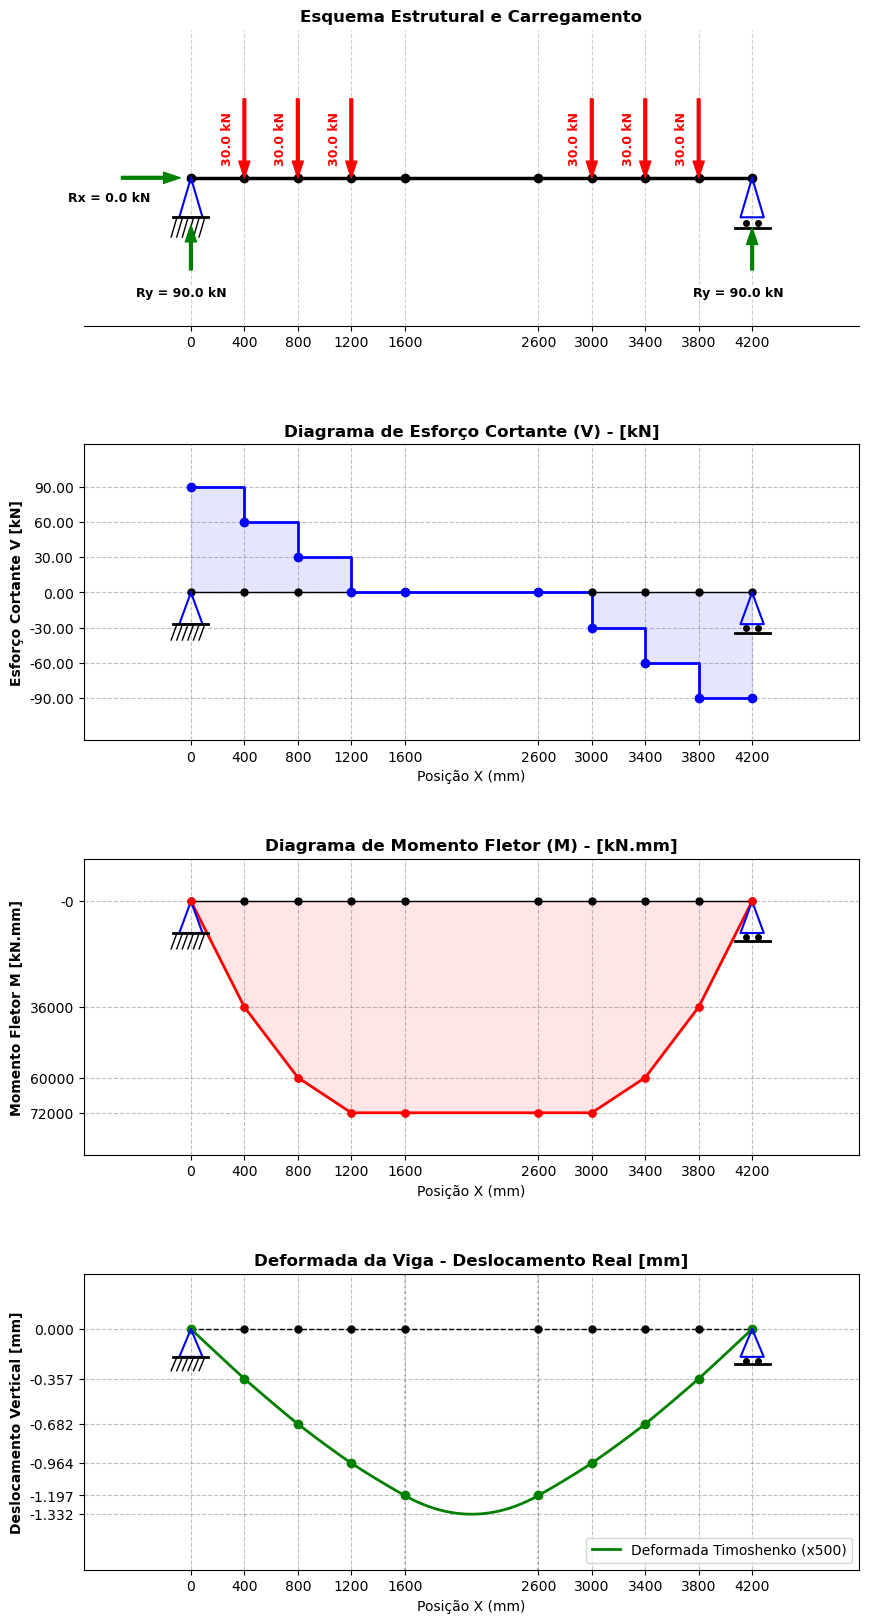

In [2]:
# ---------------------------------------------------------
# 6. EXIBIÇÃO DE RESULTADOS E GRÁFICOS
# ---------------------------------------------------------
deslocamentos_verticais = D_global[0::2]
rotacoes = D_global[1::2]

print("=== RESULTADOS DA ANÁLISE ===")
print(f"Reação Apoio Esq (Ry): {R_esq:.2f} kN")
print(f"Reação Apoio Dir (Ry): {R_dir:.2f} kN\n")

for i in range(n_nos):
    print(f"Nó {i} (x = {nos[i]:.0f} mm):")
    print(f"  Deslocamento (v) = {deslocamentos_verticais[i]:.5f} mm")
    print(f"  Rotação (theta)  = {rotacoes[i]:.5e} rad")

fig, axs = plt.subplots(4, 1, figsize=(10, 20),
                        gridspec_kw={'hspace': 0.4})

# =========================================================
# GRÁFICO 0: ESQUEMA ESTRUTURAL
# =========================================================
y_span_0 = 40.0

axs[0].plot([0, nos[-1]], [0, 0], 'k-', lw=2.5, zorder=2)
axs[0].plot(nos, np.zeros(n_nos), 'ko', markersize=6, zorder=4)

for no in nos_com_carga:
    x_val = nos[no]
    axs[0].annotate("", xy=(x_val, 0), xytext=(x_val, y_span_0*0.6),
                    arrowprops=dict(facecolor='red', edgecolor='red', width=2, headwidth=8), zorder=10)
    axs[0].text(x_val - 80, y_span_0*0.3, "30.0 kN", rotation=90, ha='right', va='center',
                color='red', fontweight='bold', fontsize=9, zorder=10)

axs[0].set_xlim(-800, 5000)
axs[0].set_ylim(-45, 45)
axs[0].yaxis.set_visible(False)
axs[0].spines['left'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].spines['top'].set_visible(False)
axs[0].set_xticks(nos)
axs[0].xaxis.grid(True, linestyle='--', alpha=0.6)

dy_g0 = 2 * y_span_0
dx_g0 = 5800

h_esq, w_esq = desenhar_apoio_2_ordem(axs[0], 0, 0, dy_g0, dx_g0)
h_dir, w_dir, gap_dir = desenhar_apoio_1_ordem(axs[0], 4200, 0, dy_g0, dx_g0)

axs[0].annotate("", xy=(0, -h_esq*1.2), xytext=(0, -28),
                arrowprops=dict(facecolor='green', edgecolor='green', width=2, headwidth=8), zorder=10)
axs[0].text(-70, -35, f"Ry = {R_esq:.1f} kN", rotation=0, ha='center', va='center', fontsize=9,
            color='black', fontweight='bold', bbox=dict(fc='white', ec='none', alpha=0.8, pad=0.2), zorder=11)

axs[0].annotate("", xy=(-80, 0), xytext=(-520, 0),
                arrowprops=dict(facecolor='green', edgecolor='green', width=2, headwidth=8), zorder=10)
axs[0].text(-610, -h_esq/2, "Rx = 0.0 kN", rotation=0, ha='center', va='center', fontsize=9,
            color='black', fontweight='bold', bbox=dict(fc='white', ec='none', alpha=0.8, pad=0.2), zorder=11)

axs[0].annotate("", xy=(4200, -h_dir-gap_dir), xytext=(4200, -28),
                arrowprops=dict(facecolor='green', edgecolor='green', width=2, headwidth=8), zorder=10)
axs[0].text(4100, -35, f"Ry = {R_dir:.1f} kN", rotation=0, ha='center', va='center', fontsize=9,
            color='black', fontweight='bold', bbox=dict(fc='white', ec='none', alpha=0.8, pad=0.2), zorder=11)

# =========================================================
# GRÁFICO 1: ESFORÇO CORTANTE
# =========================================================
axs[1].step(nos, V_elems, where='post', color='blue', lw=2, zorder=3)
axs[1].fill_between(nos, 0, V_elems, step='post', color='blue', alpha=0.1)
axs[1].plot([0, nos[-1]], [0, 0], 'k-', lw=1)
axs[1].plot(nos, np.zeros_like(nos), 'ko', markersize=5, zorder=5)
axs[1].plot(nos, V_elems, 'bo', markersize=6, zorder=6)

axs[1].set_xlim(-800, 5000)
axs[1].set_xticks(nos)
aplicar_grid_e_limites(axs[1], V_elems, 0.2)

h_esq, w_esq = desenhar_apoio_2_ordem(axs[1], 0, 0, max(V_elems)-min(V_elems), dx_g0)
h_dir, w_dir, gap_dir = desenhar_apoio_1_ordem(axs[1], 4200, 0, max(V_elems)-min(V_elems), dx_g0)

# =========================================================
# GRÁFICO 2: MOMENTO FLETOR
# =========================================================
M_z_plot = [-m for m in M_z]

axs[2].plot(X_m, M_z_plot, color='red', lw=2, zorder=3)
axs[2].fill_between(X_m, 0, M_z_plot, color='red', alpha=0.1)
axs[2].plot([0, nos[-1]], [0, 0], 'k-', lw=1)
axs[2].plot(nos, np.zeros_like(nos), 'ko', markersize=5, zorder=5)
axs[2].plot(X_m, M_z_plot, 'ro', markersize=5, zorder=6)

axs[2].set_xlim(-800, 5000)
axs[2].set_xticks(nos)
aplicar_grid_e_limites(axs[2], M_z_plot, 0.2)

ticks = axs[2].get_yticks()
axs[2].set_yticklabels([f"{-t:g}" for t in ticks])

h_esq, w_esq = desenhar_apoio_2_ordem(axs[2], 0, 0, max(M_z_plot)-min(M_z_plot), dx_g0)
h_dir, w_dir, gap_dir = desenhar_apoio_1_ordem(axs[2], 4200, 0, max(M_z_plot)-min(M_z_plot), dx_g0)

# =========================================================
# GRÁFICO 3: DEFORMADA (Com Funções de Forma de Timoshenko)
# =========================================================
def interpolacao_timoshenko(v_i, theta_i, v_j, theta_j, L, E, G, I, As, num_pontos=50):
    Phi = (12.0 * E * I) / (G * As * L**2)
    x_local = np.linspace(0, L, num_pontos)
    xi = x_local / L
    
    N1 = 1 / (1 + Phi) * (1 - 3*xi**2 + 2*xi**3 + Phi*(1 - xi))
    N2 = L / (1 + Phi) * (xi - 2*xi**2 + xi**3 + (Phi/2)*(xi - xi**2))
    N3 = 1 / (1 + Phi) * (3*xi**2 - 2*xi**3 + Phi*xi)
    N4 = L / (1 + Phi) * (-xi**2 + xi**3 - (Phi/2)*(xi - xi**2))
    
    v_local = N1*v_i + N2*theta_i + N3*v_j + N4*theta_j
    return x_local, v_local

x_deformada = []
y_deformada = []

for el in elementos:
    no_i, no_j, I_el, As_el = el
    L = nos[no_j] - nos[no_i]
    gls = [2*no_i, 2*no_i+1, 2*no_j, 2*no_j+1]
    
    v_i, theta_i, v_j, theta_j = D_global[gls]
    x_loc, v_loc = interpolacao_timoshenko(v_i, theta_i, v_j, theta_j, L, E, G, I_el, As_el)
    
    if el == elementos[-1]:
        x_deformada.extend(nos[no_i] + x_loc)
        y_deformada.extend(v_loc)
    else:
        x_deformada.extend((nos[no_i] + x_loc)[:-1])
        y_deformada.extend(v_loc[:-1])

x_deformada = np.array(x_deformada)
y_deformada = np.array(y_deformada)

deflexao_max = min(y_deformada)
x_max = x_deformada[np.argmin(y_deformada)]
print(f"\n-> Deflexão Máxima Real (Timoshenko): {deflexao_max:.3f} mm (em x = {x_max:.0f} mm)")

fator_escala = 500
disp_amp_curva = y_deformada * fator_escala
disp_amp_nos = deslocamentos_verticais * fator_escala

axs[3].plot(x_deformada, disp_amp_curva, 'g-', lw=2, zorder=3, label=f"Deformada Timoshenko (x{fator_escala})")
axs[3].plot(nos, disp_amp_nos, 'go', markersize=6, zorder=5)
axs[3].plot([0, nos[-1]], [0, 0], 'k--', lw=1)
axs[3].plot(nos, np.zeros_like(nos), 'ko', markersize=5, zorder=4)

axs[3].set_xlim(-800, 5000)
axs[3].set_xticks(nos)
axs[3].axvline(x=1600, color='gray', linestyle=':', alpha=0.5)
axs[3].axvline(x=2600, color='gray', linestyle=':', alpha=0.5)

valores_y_para_grid = np.append(disp_amp_nos, min(disp_amp_curva))
aplicar_grid_e_limites(axs[3], valores_y_para_grid, 0.3)

ticks = axs[3].get_yticks()
axs[3].set_yticklabels([f"{t/fator_escala:.3f}" for t in ticks])
axs[3].legend(loc="lower right")

h_esq, w_esq = desenhar_apoio_2_ordem(axs[3], 0, 0, max(disp_amp_curva)-min(disp_amp_curva), dx_g0)
h_dir, w_dir, gap_dir = desenhar_apoio_1_ordem(axs[3], 4200, 0, max(disp_amp_curva)-min(disp_amp_curva), dx_g0)

# =========================================================
# FORMATAÇÃO FINAL
# =========================================================
axs[0].set_title("Esquema Estrutural e Carregamento", fontweight='bold')
axs[1].set_title("Diagrama de Esforço Cortante (V) - [kN]", fontweight='bold')
axs[1].set_ylabel("Esforço Cortante V [kN]", fontweight='bold')
axs[2].set_title("Diagrama de Momento Fletor (M) - [kN.mm]", fontweight='bold')
axs[2].set_ylabel("Momento Fletor M [kN.mm]", fontweight='bold')
axs[3].set_title("Deformada da Viga - Deslocamento Real [mm]", fontweight='bold')
axs[3].set_ylabel("Deslocamento Vertical [mm]", fontweight='bold')

for ax in axs[1:]:
    ax.set_xlabel("Posição X (mm)")

plt.show()